# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
# Используйте ячейки типа Code для вашего кода,
# а ячейки типа Markdown для комментариев и выводов

In [2]:
# При необходимости добавляйте новые ячейки для кода или текста

In [3]:
import pandas as pd

In [4]:
import numpy as np

In [5]:
import matplotlib.pyplot as plt 
import seaborn as sns 

In [6]:
from sqlalchemy import create_engine #необходимо для sql query  чтоб прочесть данный из базы

In [7]:
!pip install phik -q

In [8]:
from phik import phik_matrix #необходимо для заданий 

In [9]:
import os
from dotenv import load_dotenv
load_dotenv()

db_config = {'user': os.getenv('DB_USER'), # имя пользователя
             'pwd':  os.getenv('DB_PASSWORD'), # пароль
             'host': os.getenv('DB_HOST'),
             'port': os.getenv('DB_PORT'), # порт подключения
             'db': os.getenv('DB_NAME') # название базы данных
             } 

In [10]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

In [11]:
engine = create_engine(connection_string) 

In [12]:
query = '''
WITH gap AS (
    SELECT 
        order_id,              -- ДОБАВЛЕНО: нужен уникальный ключ для JOIN
        user_id,
        created_dt_msk, 
        LAG (created_dt_msk) OVER (PARTITION BY user_id ORDER BY created_dt_msk) AS lagging 
    FROM   
        afisha.purchases
),
gap_days AS (
    SELECT 
        order_id,               -- ДОБАВЛЕНО: передаём дальше уникальный ключ
        user_id, 
        created_dt_msk, 
        (created_dt_msk::date - lagging::date)::int AS days_since_prev
    FROM 
        gap
), 
main AS (
    SELECT 
        p.*, gap_days.days_since_prev
    FROM 
        afisha.purchases p 
    JOIN gap_days 
        ON p.order_id = gap_days.order_id   -- ИЗМЕНЕНО: было user_id + created_dt_msk
)
SELECT 
    p.user_id, 
    p.device_type_canonical, 
    p.order_id,
    p.created_dt_msk AS order_dt, 
    p.created_ts_msk AS order_ts,
    p.currency_code, 
    p.revenue, 
    p.tickets_count, 
    m.days_since_prev, 
    p.event_id,
    e.event_name_code AS event_name, 
    e.event_type_main, 
    p.service_name,
    r.region_name,
    c.city_name
FROM 
    afisha.purchases p 
    LEFT JOIN main m 
        ON p.order_id = m.order_id          -- ИЗМЕНЕНО: было user_id + created_dt_msk
    LEFT JOIN afisha.events e 
        ON p.event_id = e.event_id
    LEFT JOIN afisha.city c
        ON e.city_id = c.city_id 
    LEFT JOIN afisha.regions r 
        ON c.region_id = r.region_id 
WHERE 
    p.device_type_canonical IN ('mobile', 'desktop') 
    AND e.event_type_main <> 'фильм'
ORDER BY p.user_id;
''' 

In [13]:
df = pd.read_sql_query(query, con=engine) 

In [14]:
df

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290606,fffcd3dde79eb2c,desktop,7100332,2024-09-27,2024-09-27 22:48:10,rub,153.13,1,2.0,553741,7ca9bb1a-3a11-4659-b09c-b3fb8a1bd6bb,концерты,Облачко,Широковская область,Радужнополье
290607,fffcd3dde79eb2c,mobile,3260007,2024-08-04,2024-08-04 11:25:14,rub,213.81,3,45.0,554265,b858d12c-812d-402a-8a87-5d7769333569,спорт,Лучшие билеты,Каменевский регион,Глиногорск
290608,fffcd3dde79eb2c,mobile,8064785,2024-08-21,2024-08-21 21:25:20,rub,814.51,3,0.0,516365,93a44527-9791-49c9-a688-13ff140e2aab,концерты,Лови билет!,Яблоневская область,Светополье
290609,fffeeb3c120cf0b,desktop,5526067,2024-09-24,2024-09-24 10:07:42,rub,661.53,2,NaN,454526,6f4c6a50-0106-407b-8f54-332c740b01da,стендап,Билеты без проблем,Широковская область,Ягодиновка


---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [15]:
df.info() # информация о пропусках и типах информации сохраненных в столбцах

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268740 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


In [16]:
df.head(10) # Выводим первые строки датафрейма на экран

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк
5,000898990054619,mobile,2613713,2024-10-23,2024-10-23 15:12:00,rub,902.74,3,19.0,500862,9cc55c15-4375-4129-9979-3129688ba1b4,концерты,Облачко,Лугоградская область,Кристалевск
6,00096d1f542ab2b,desktop,6636941,2024-08-15,2024-08-15 16:48:48,rub,917.83,4,NaN,201953,2f98d69f-4e60-4ffc-8f16-e539383526b1,театр,Край билетов,Каменевский регион,Глиногорск
7,000a55a418c128c,mobile,4657952,2024-10-15,2024-10-15 10:29:04,rub,74.84,2,16.0,271579,ddc795f8-7ef8-4eb0-b299-cb3e6ee24ba1,театр,Лучшие билеты,Поленовский край,Дальнозолотск
8,000a55a418c128c,mobile,4657981,2024-09-29,2024-09-29 19:39:12,rub,47.78,1,NaN,265857,0d876e01-851e-458b-ba61-753e0e0c4063,театр,Лучшие билеты,Поленовский край,Дальнозолотск
9,000cf0659a9f40f,mobile,6818162,2024-06-21,2024-06-21 04:18:44,rub,1066.43,3,0.0,516728,11be386f-7cb7-4aa1-a8e4-ba73a29c1af2,концерты,Лови билет!,Широковская область,Радужнополье


# вывод
Всего строк: 290 611.

Всего колонок: 15.

Пропусков почти нет. Только одна колонка с пропусками: days_since_prev. Заполнено 268 740 из 290 611.

Типы данных не меняем:

Текст (object): 8 колонок.
Числа целые (int64): 3 колонки.
Числа дробные (float64): 2 колонки.
Дата и время (datetime64): 2 колонки.

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [17]:
valuta = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv') #прочитаем файл курс валюты

In [18]:
valuta.info()

<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    str    
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    str    
dtypes: float64(1), int64(1), str(2)
memory usage: 11.3 KB


In [19]:
valuta.head(5)

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [20]:
valuta['data']=pd.to_datetime(valuta['data']) #меняем категорию типа данных для даты в файле курс валюты из object  в  datetime

In [21]:
valuta.info()

<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   data     357 non-null    datetime64[us]
 1   nominal  357 non-null    int64         
 2   curs     357 non-null    float64       
 3   cdx      357 non-null    str           
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 11.3 KB


In [22]:
df = df.merge(valuta[['curs', 'data']], left_on = 'order_dt', right_on = 'data', how = 'left') #добавим курс валюты для соответствующей даты

In [23]:
df.head(2)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,curs,data
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,18.6972,2024-08-20
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,18.3419,2024-07-23


In [24]:
df['revenue_rub'] = df['revenue'] #скопируем доход в новый столб 

In [25]:
df.loc[df['currency_code'] == 'kzt', 'revenue_rub'] = df['revenue'] * df['curs'] / 100 #подсчитаем какова рублевая доходность для дохода в тенге 

In [26]:
df = df.drop (columns = ['data']) # удалим не нужный столб с датой из файлы курс вылют

In [27]:
df['revenue_rub'] = df['revenue_rub'].round(2) #округлим revenue_rub много чисел занимают много памяти 

In [28]:
df['curs'] = df['curs'].round(2) #округлим curs много чисел занимают много памяти 

In [29]:
df.head(10)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,curs,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,18.70,1521.94
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,18.34,289.45
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск,19.65,1258.57
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск,18.50,8.49
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк,19.66,1390.41
5,000898990054619,mobile,2613713,2024-10-23,2024-10-23 15:12:00,rub,902.74,3,19.0,500862,9cc55c15-4375-4129-9979-3129688ba1b4,концерты,Облачко,Лугоградская область,Кристалевск,20.05,902.74
6,00096d1f542ab2b,desktop,6636941,2024-08-15,2024-08-15 16:48:48,rub,917.83,4,NaN,201953,2f98d69f-4e60-4ffc-8f16-e539383526b1,театр,Край билетов,Каменевский регион,Глиногорск,18.77,917.83
7,000a55a418c128c,mobile,4657952,2024-10-15,2024-10-15 10:29:04,rub,74.84,2,16.0,271579,ddc795f8-7ef8-4eb0-b299-cb3e6ee24ba1,театр,Лучшие билеты,Поленовский край,Дальнозолотск,19.72,74.84
8,000a55a418c128c,mobile,4657981,2024-09-29,2024-09-29 19:39:12,rub,47.78,1,NaN,265857,0d876e01-851e-458b-ba61-753e0e0c4063,театр,Лучшие билеты,Поленовский край,Дальнозолотск,19.37,47.78
9,000cf0659a9f40f,mobile,6818162,2024-06-21,2024-06-21 04:18:44,rub,1066.43,3,0.0,516728,11be386f-7cb7-4aa1-a8e4-ba73a29c1af2,концерты,Лови билет!,Широковская область,Радужнополье,18.58,1066.43


---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
</font><font color='Blue'><b> Комментарий МК: Только одна колонка с пропусками: days_since_prev</b></font><br> 

- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем </font><font color='Blue'><b> Комментарий МК: Ничего менять не надо</b></font><br>  а также на числовые данные, размерность которых можно сократить.
</font><font color='Blue'><b> Комментарий МК: Curs & Revenue_rub  были преобразованы уже</b></font><br> 
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268740 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


In [31]:
print(df['user_id'].nunique())
print(df['order_id'].nunique())
print(df['event_id'].nunique())
print(df['event_name'].nunique())
print(df['service_name'].nunique())
print(df['days_since_prev'].nunique())

21933
290611
22427
15248
36
149


In [32]:
#вывод уникальных отсортированных значений 
print(df['event_type_main'].unique())
print(df['device_type_canonical'].unique())
print(df['currency_code'].unique())
print(sorted(df['service_name'].unique()))
print(sorted(df['region_name'].unique()))
print(sorted(df['city_name'].unique()))

<StringArray>
['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт', 'ёлки']
Length: 7, dtype: str
<StringArray>
['mobile', 'desktop']
Length: 2, dtype: str
<StringArray>
['rub', 'kzt']
Length: 2, dtype: str
['Crazy ticket!', 'Show_ticket', 'Билет по телефону', 'Билеты без проблем', 'Билеты в интернете', 'Билеты в руки', 'Быстробилет', 'Быстрый кассир', 'Весь в билетах', 'Восьмёрка', 'Вперёд!', 'Выступления.ру', 'Городской дом культуры', 'Дом культуры', 'Дырокол', 'За билетом!', 'Зе Бест!', 'КарандашРУ', 'Кино билет', 'Край билетов', 'Лимоны', 'Лови билет!', 'Лучшие билеты', 'Мир касс', 'Мой билет', 'Облачко', 'Прачечная', 'Радио ticket', 'Реестр', 'Росбилет', 'Тебе билет!', 'Телебилет', 'Тех билет', 'Цвет и билет', 'Шоу начинается!', 'Яблоко']
['Белоярская область', 'Берестовский округ', 'Берёзовская область', 'Боровлянский край', 'Верховинская область', 'Верхозёрский край', 'Верхоречная область', 'Ветренский регион', 'Вишнёвский край', 'Глиногорская область', 'Голубевский ок

</font><font color='Blue'><b> Комментарий МК</b></font><br>
ВЫВОД: вывод уникальных отсортированных значений показывает что в нормализации данных нет необходимости. пропуски в days_since_prev ожидаемы, больше пропусков нет. Уникальные значения не дают NAN 
в каком либо столбце

- Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.

Важные показатели в рамках поставленной задачи — это выручка с заказа (revenue_rub) и количество билетов в заказе (tickets_count), поэтому в первую очередь проверьте данные в этих столбцах.

Если обнаружите выбросы в поле revenue_rub, то отфильтруйте значения по 99 перцентилю.

In [33]:
df['revenue_rub'].describe() #посмотреть статистику дохода

count    290611.000000
mean        555.571989
std         875.498170
min         -90.760000
25%         113.970000
50%         351.140000
75%         802.050000
max       81174.540000
Name: revenue_rub, dtype: float64

In [34]:
count = (df['revenue_rub']<0).sum() #подсчет сколько раз доход встречается меньше 0 
print(count)

381


In [35]:
df = df[df['revenue_rub']>=0] #убираем все отрицательные доходы

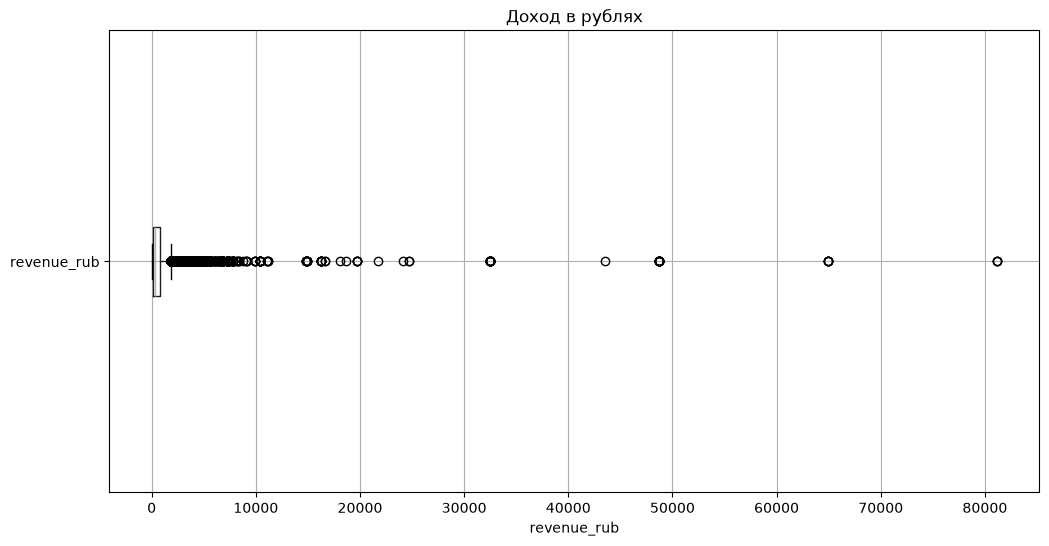

In [36]:
# Создаём контейнер графика
plt.figure(figsize=(12, 6))

# Строим boxplot для данных
df.boxplot(column='revenue_rub', vert=False)

# Добавляем заголовок и метки
plt.title('Доход в рублях')
plt.xlabel('revenue_rub')

# Выводим график
plt.show()

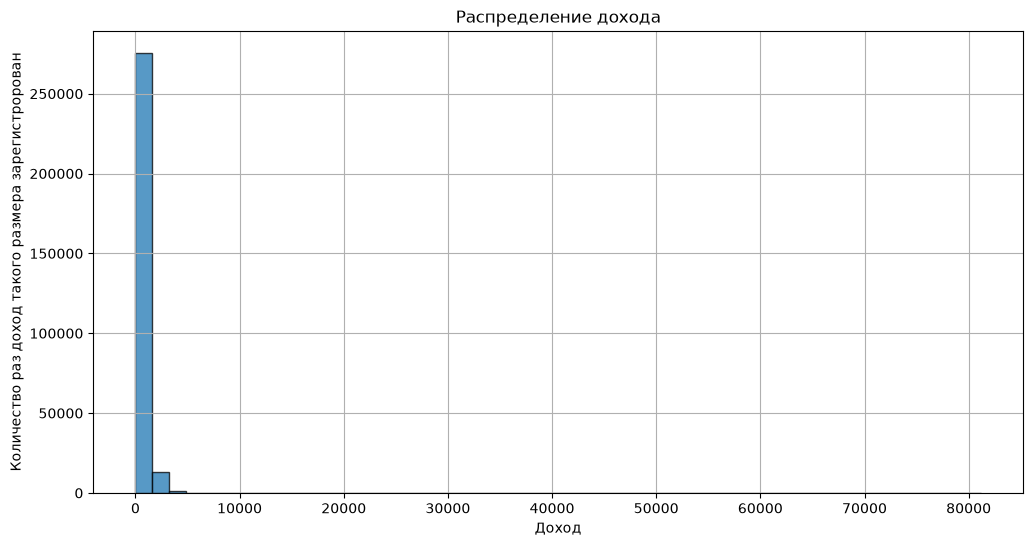

In [37]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df['revenue_rub'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=50, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение дохода')
plt.xlabel('Доход')
plt.ylabel('Количество раз доход такого размера зарегистророван')
# Добавляем сетку графика
plt.grid()
#plt.yscale('log') #добавили чтоб видеть все доходы даже повторяющиеся одиножды
# Выводим график
plt.show()

In [38]:
porog = df['revenue_rub'].quantile(0.99) # ниже  находится 99% заказов. Только 1% заказов имеет выручку выше этого значения
print(porog)

2628.42


In [39]:
df = df[df['revenue_rub']<=porog] #берем только значния в лимите 99 персентиля

In [40]:
df['tickets_count'].describe()

count    287405.000000
mean          2.741323
std           1.163087
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max          57.000000
Name: tickets_count, dtype: float64

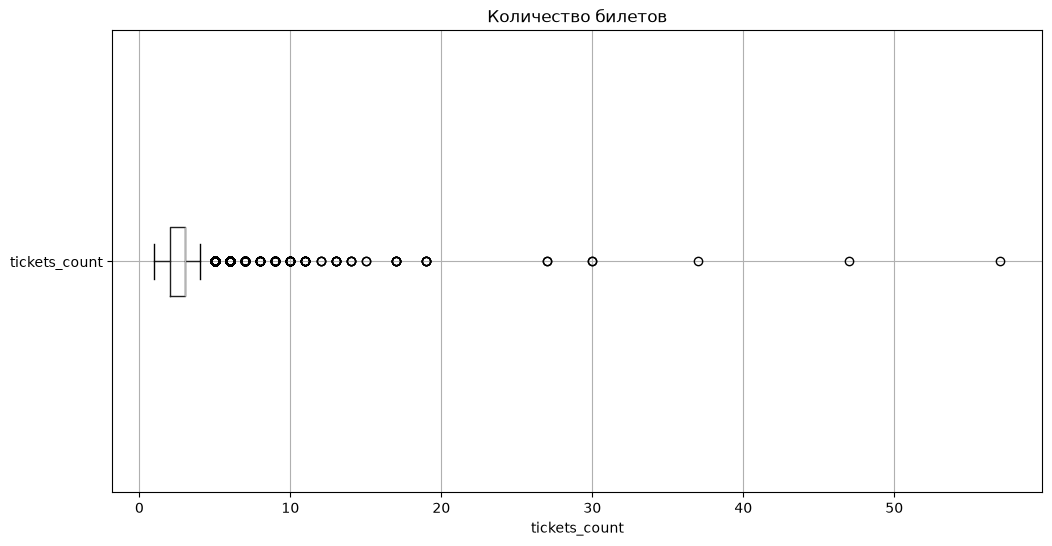

In [41]:
# Создаём контейнер графика
plt.figure(figsize=(12, 6))

# Строим boxplot для данных
df.boxplot(column='tickets_count', vert=False)

# Добавляем заголовок и метки
plt.title('Количество билетов')
plt.xlabel('tickets_count')

# Выводим график
plt.show()

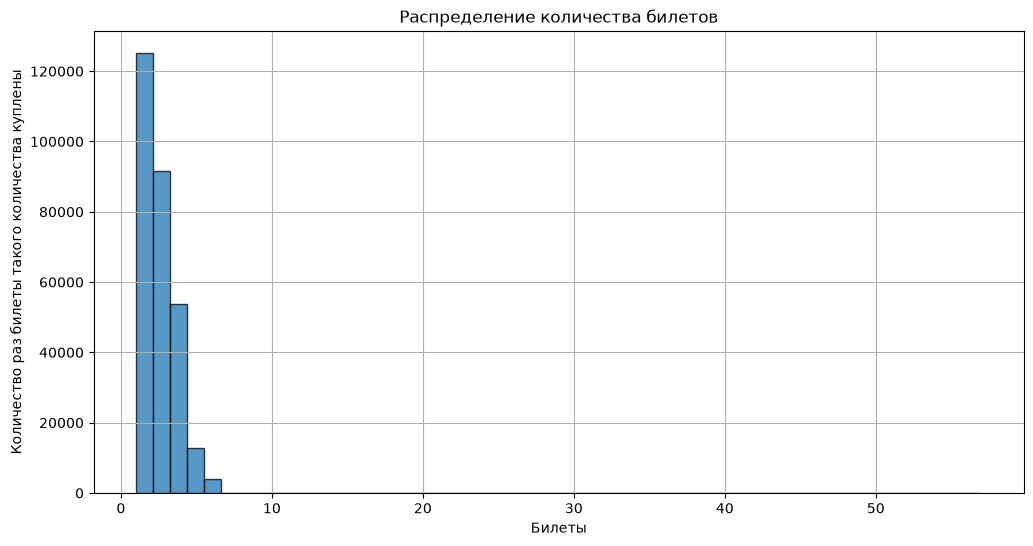

In [42]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df['tickets_count'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=50, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение количества билетов')
plt.xlabel('Билеты')
plt.ylabel('Количество раз билеты такого количества куплены')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

</font><font color='Blue'><b> Комментарий МК</b></font><br>
# Вывод: 
Доход (revenue_rub):

Среднее значение: 555 рублей.
Большинство доходов небольшие (от 113 до 802 рублей).
Были аномально большие значения. Максимум — 81174 рубля.
Были отрицательные значения. Их было 381 штука. Ты их удалил.
Отфильтрованы верхние выбросы по 99 перцентилю.

Билеты (tickets_count):

Обычно покупают от 2 до 3 билетов.
Есть выбросы. Максимум — 57 билетов.

In [43]:
df.info()

<class 'pandas.DataFrame'>
Index: 287405 entries, 0 to 290610
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                287405 non-null  str           
 1   device_type_canonical  287405 non-null  str           
 2   order_id               287405 non-null  int64         
 3   order_dt               287405 non-null  datetime64[us]
 4   order_ts               287405 non-null  datetime64[us]
 5   currency_code          287405 non-null  str           
 6   revenue                287405 non-null  float64       
 7   tickets_count          287405 non-null  int64         
 8   days_since_prev        265772 non-null  float64       
 9   event_id               287405 non-null  int64         
 10  event_name             287405 non-null  str           
 11  event_type_main        287405 non-null  str           
 12  service_name           287405 non-null  str           
 13  

</font><font color='Blue'><b> Комментарий МК</b></font><br>
Промежуточный вывод
Данные отфильтрованы. Было 290611 строк, стало 287405.

Удалено 3206 строк. Это 1.1% от всех данных.

Что именно удалено:

381 строка — отрицательный доход (revenue_rub < 0).
Остальные 2825 строк — аномально большие доходы (выше 99 перцентиля).
Фильтр по 99 перцентилю теперь сработал. В прошлый раз он не применился из-за ошибки в коде. Сейчас всё исправлено.

Новые колонки не появились. 

Пропуски логично уменьшились. days_since_prev — было 268740, стало 265772. Разница связана с удалёнными строками.

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [44]:
profile = df #создаем профиль датафрейм

In [45]:
profile = profile.drop(columns = ['currency_code', 'revenue', 'curs']) #убираем ненужные колонки которые не нужны профилю

In [46]:
profile = profile.sort_values(['user_id', 'order_ts']) #нас интересует значения первые соответсвенно соритируем ASC

user_info = profile.groupby('user_id').agg(
    first_order=('order_ts', 'min'),
    last_order=('order_ts', 'max'),
    first_order_device=('device_type_canonical', 'first'),
    first_order_region=('region_name', 'first'),
    first_order_service=('service_name', 'first'),
    first_order_genre=('event_type_main', 'first'),
    orders_count=('order_id', 'count'),
    avg_revenue_rub=('revenue_rub', 'mean'),
    avg_tickets_count=('tickets_count', 'mean'),
    avg_days_between_orders=('days_since_prev', 'mean')
).reset_index()

user_info['is_two'] = np.where(user_info['orders_count'] >= 2, 'yes', 'no')
user_info['is_five'] = np.where(user_info['orders_count'] >= 5, 'yes', 'no')

In [47]:
profile = profile.merge(user_info, on = 'user_id', how = 'left')

In [48]:
profile.head(6)

,user_id,device_type_canonical,order_id,order_dt,order_ts,tickets_count,days_since_prev,event_id,event_name,event_type_main,...,first_order_device,first_order_region,first_order_service,first_order_genre,orders_count,avg_revenue_rub,avg_tickets_count,avg_days_between_orders,is_two,is_five
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,...,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaN,no,no
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,...,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.0,yes,no
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,...,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.0,yes,no
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,...,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0,yes,no
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,...,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0,yes,no
5,000898990054619,mobile,2613713,2024-10-23,2024-10-23 15:12:00,3,19.0,500862,9cc55c15-4375-4129-9979-3129688ba1b4,концерты,...,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0,yes,no


---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [49]:
#общее число пользователей в выборке;
#среднюю выручку с одного заказа;
#долю пользователей, совершивших 2 и более заказа;
#долю пользователей, совершивших 5 и более заказов.

In [50]:
#среднюю выручку с одного заказа
unique_users =profile['user_id'].nunique()
avg_revenue_per_order = profile['revenue_rub'].mean()
dolya_polzovatelei_dva = (user_info['orders_count'] >= 2).mean()
dolya_polzovatelei_pyat = (user_info['orders_count'] >= 5).mean()
print('Уникальные клиенты - ', unique_users)
print()
print('Средняя выручка с одного заказа - ', avg_revenue_per_order)
print()
print('Доля пользователей, совершивших 2 и более заказов - ', dolya_polzovatelei_dva)
print()
print('Доля пользователей, совершивших 5 и более заказов - ', dolya_polzovatelei_pyat)

Уникальные клиенты -  21838

Средняя выручка с одного заказа -  518.7192594770446

Доля пользователей, совершивших 2 и более заказов -  0.6170436853191684

Доля пользователей, совершивших 5 и более заказов -  0.28995329242604634


In [51]:
user_info[['orders_count', 'avg_tickets_count', 'avg_days_between_orders']].describe()

,orders_count,avg_tickets_count,avg_days_between_orders
count,21838.000000,21838.000000,13524.000000
mean,13.160775,2.744062,15.868456
std,121.577370,0.913083,22.320184
min,1.000000,1.000000,0.000000
25%,1.000000,2.000000,1.000000
50%,2.000000,2.750000,8.000000
75%,5.000000,3.080000,20.500000
max,10168.000000,11.000000,148.000000


In [52]:
#по общему числу заказов;
#по среднему числу билетов в заказе;
#по среднему количеству дней между покупками.

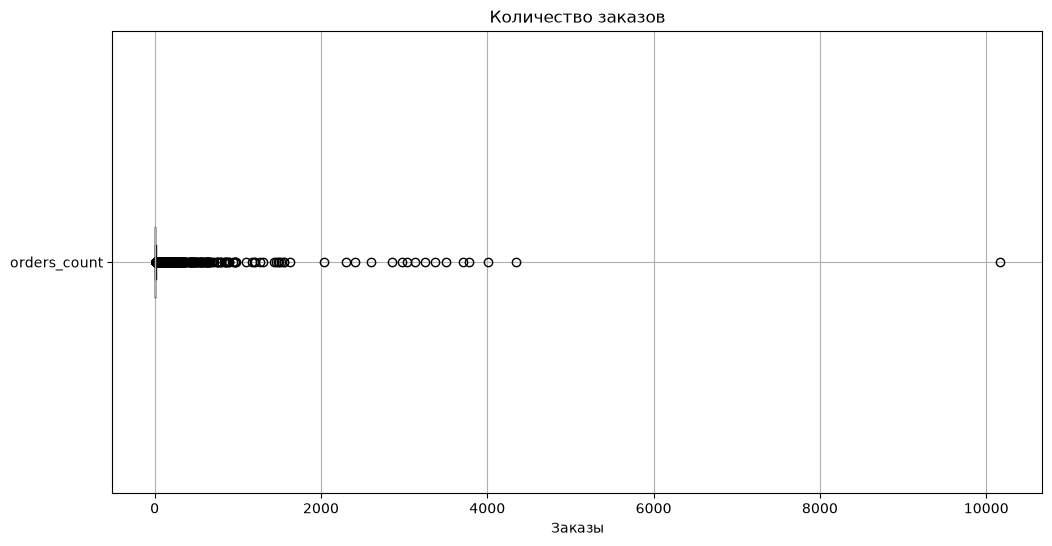

In [53]:
# Создаём контейнер графика
plt.figure(figsize=(12, 6))

# Строим boxplot для данных
user_info.boxplot(column='orders_count', vert=False)

# Добавляем заголовок и метки
plt.title('Количество заказов')
plt.xlabel('Заказы')

# Выводим график
plt.show()

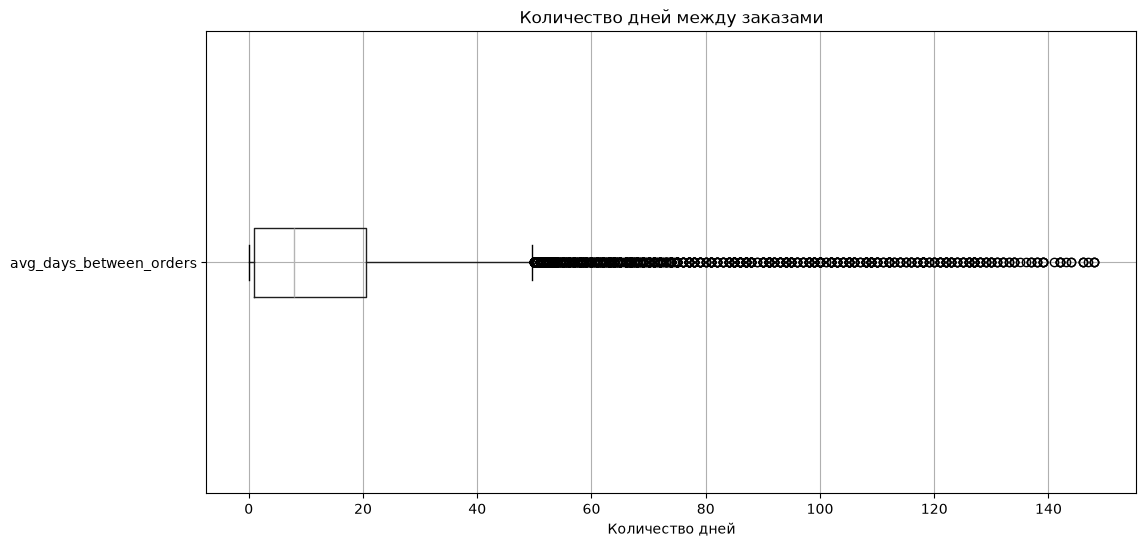

In [54]:
# Создаём контейнер графика
plt.figure(figsize=(12, 6))

# Строим boxplot для данных
user_info.boxplot(column='avg_days_between_orders', vert=False)

# Добавляем заголовок и метки
plt.title('Количество дней между заказами')
plt.xlabel('Количество дней')

# Выводим график
plt.show()

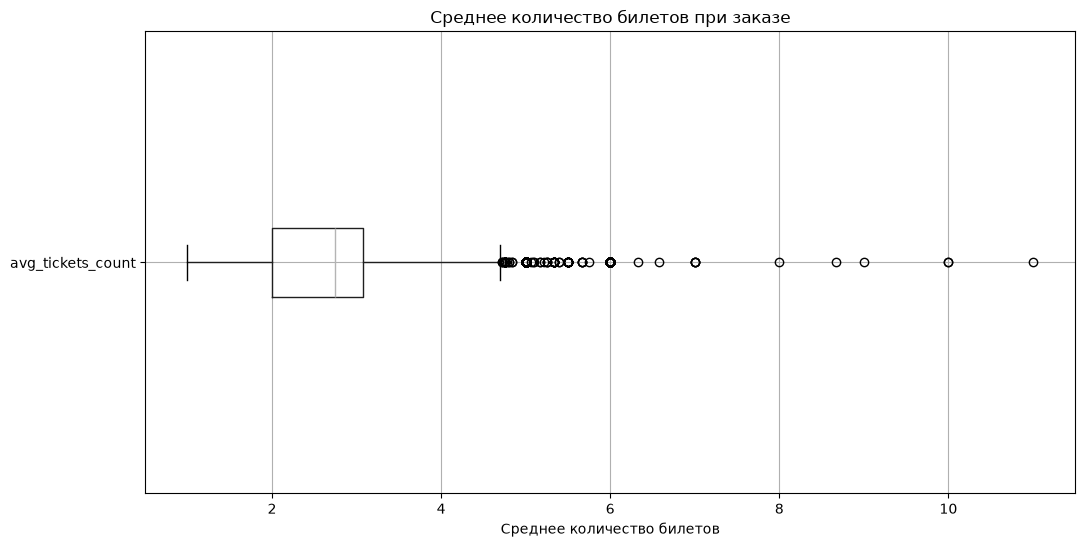

In [55]:
# Создаём контейнер графика
plt.figure(figsize=(12, 6))

# Строим boxplot для данных
user_info.boxplot(column='avg_tickets_count', vert=False)

# Добавляем заголовок и метки
plt.title('Среднее количество билетов при заказе')
plt.xlabel('Среднее количество билетов')

# Выводим график
plt.show()

- Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:
- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?
- Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

</font><font color='Blue'><b> Комментарий МК</b></font><br>
orders_count — точно нужно чистить.Будем чистить как чистили изначально 'revenue_rub' по 99 перцентилю

Среднее — 20.6. Медиана — всего 4.0. Разница большая. Максимум — 10168 заказов у одного человека. Это явный выброс. Скорее всего, бот или ошибка. Нужно почистить.

avg_tickets_count — тоже в порядке.

Среднее и медиана совпадают. Разброс маленький. Чистить не нужно.

avg_days_between_orders — под вопросом.

Среднее — 15.8. Медиана — 8.0. Разница заметная но не критичная. Задача нацелена на то что клиенты вернулись так что оставляем важные показатели. Тем более выбросы частые а не одна единственная или несколько заброшенных очень далеко от медианы.

In [56]:
profile_clean= profile['orders_count'].quantile(0.99)
print(profile_clean)

10168.0


In [57]:
profile= profile[profile['orders_count']<= profile_clean]

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [58]:
columns = ['device_type_canonical', 'event_type_main', 'service_name', 'region_name']

In [59]:
#pd.set_option('display.max_rows', None)
for col in columns:
    count = profile.groupby(col)['user_id'].nunique()
    share = profile.groupby(col)['user_id'].nunique()/profile['user_id'].nunique() *100
    print (f'----{col}----')
    print()
    print('Count', count)
    print()
    print('Share', share)
    print()
    

----device_type_canonical----

Count device_type_canonical
desktop     7087
mobile     19703
Name: user_id, dtype: int64

Share device_type_canonical
desktop    32.452606
mobile     90.223464
Name: user_id, dtype: float64

----event_type_main----

Count event_type_main
выставки     1600
другое       9264
концерты    13340
спорт        2533
стендап      3241
театр        8238
ёлки          707
Name: user_id, dtype: int64

Share event_type_main
выставки     7.326678
другое      42.421467
концерты    61.086180
спорт       11.599048
стендап     14.841103
театр       37.723235
ёлки         3.237476
Name: user_id, dtype: float64

----service_name----

Count service_name
Crazy ticket!              340
Show_ticket                774
Билет по телефону           54
Билеты без проблем        8819
Билеты в интернете           4
Билеты в руки             5708
Быстробилет                796
Быстрый кассир             202
Весь в билетах            3655
Восьмёрка                  419
Вперёд!          

</font><font color='Blue'><b> Комментарий МК</b></font><br>
Нет, распределение неравномерное. Есть чёткие точки входа.

Устройство:

Мобильный телефон — главная точка входа. 90.2% пользователей. Десктоп — 32.5% (многие пользуются и тем, и другим).

Тип мероприятия:

Концерты — главная точка входа. 61.1% пользователей. Дальше "другое" (42.4%) и театр (37.7%).

Сервис:

"Билеты без проблем" — лидер, 40.4%. Следом "Лови билет!" (29.1%), "Мой билет" (28.5%), "Облачко" (24.5%), "Билеты в руки" (26.1%). Явного монополиста нет, но 5 сервисов явно выделяются на фоне остальных (у большинства долей меньше 5%).

Регион:

Каменевский регион — явный лидер, 48.3% всех пользователей. Дальше Североярская область (30.6%) и Широковская область (14.9%). Остальные регионы — меньше 10%.

Вывод
По всем признакам есть выраженные точки входа. Особенно сильно выделяются: мобильные устройства, концерты, Каменевский регион. Равномерного распределения нет нигде.

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


--- first_order_device ---
first_order_device
desktop    64.140875
mobile     61.199558
Name: user_id, dtype: float64



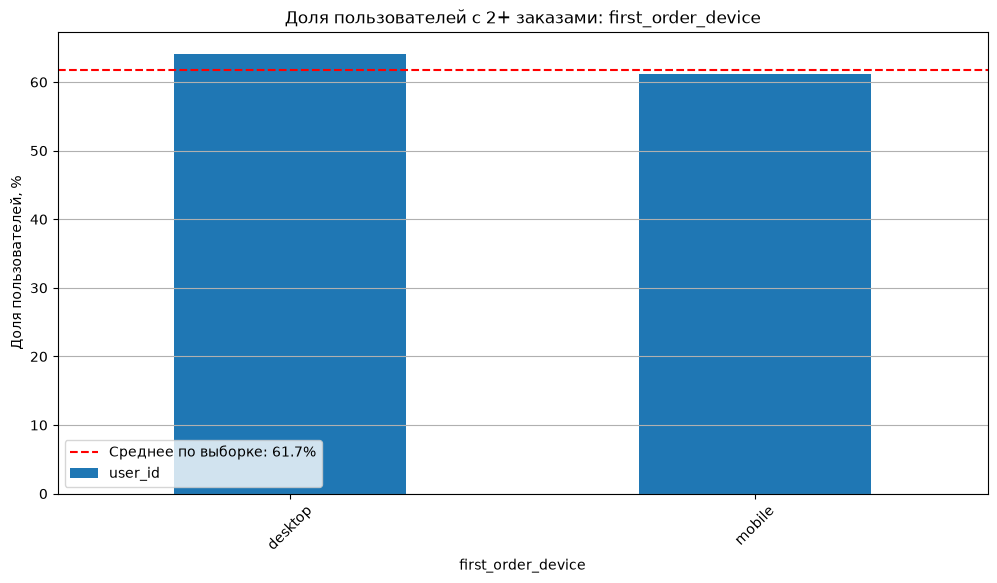

--- first_order_genre ---
first_order_genre
выставки    64.508393
театр       63.864959
концерты    62.143672
стендап     61.180680
другое      60.036597
спорт       56.179775
ёлки        55.789474
Name: user_id, dtype: float64



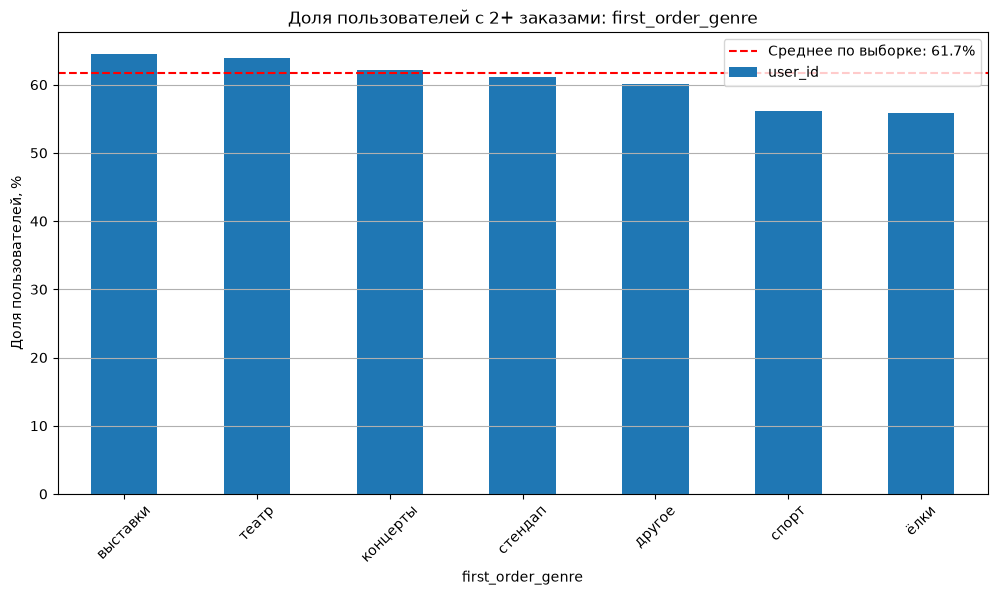

--- first_order_service ---
first_order_service
Край билетов          65.577342
Дом культуры          64.804469
Весь в билетах        63.448276
Билеты в руки         63.271605
Прачечная             62.925170
Облачко               61.531449
Лови билет!           61.487197
Лучшие билеты         61.467116
Мой билет             61.176078
Билеты без проблем    60.607225
Name: user_id, dtype: float64



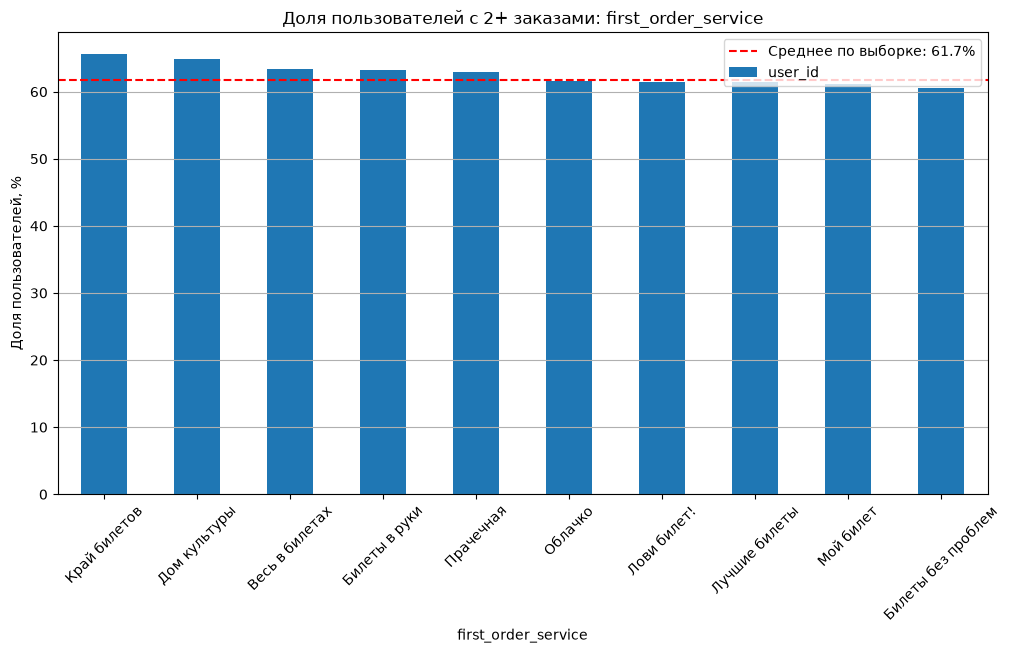

--- first_order_region ---
first_order_region
Шанырский регион        67.524752
Светополянский округ    66.163793
Широковская область     64.805825
Североярская область    64.131579
Речиновская область     63.901345
Каменевский регион      62.779330
Травяная область        61.866126
Яблоневская область     59.855769
Малиновоярский округ    56.226415
Озернинский край        55.457227
Name: user_id, dtype: float64



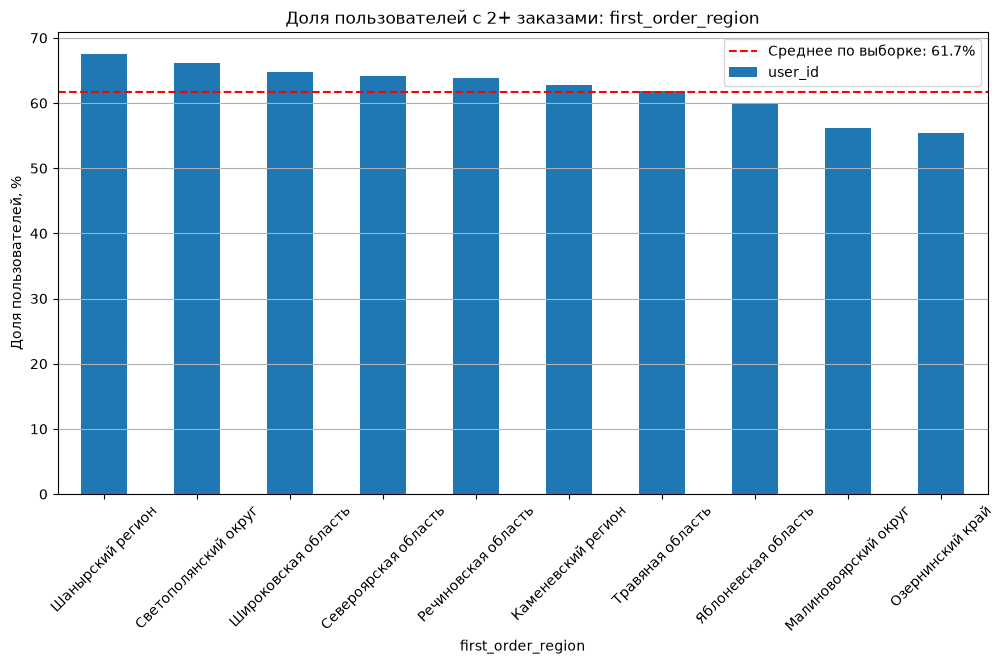

In [60]:
#используем признаки первого заказа из user_info
columns = [
    'first_order_device',
    'first_order_genre',
    'first_order_service',
    'first_order_region'
]

# названия колонок из user_info
top_n_columns = ['first_order_service', 'first_order_region']

# используем user_info, где одна строка на пользователя
filtered = user_info[user_info['is_two'] == 'yes']

#  средняя доля возврата по всей выборке
overall_share = (user_info['is_two'] == 'yes').mean() * 100

for col in columns:
    plt.figure(figsize=(12, 6))

    # все пользователи каждого сегмента
    all_users = user_info.groupby(col)['user_id'].nunique()

    # число вернувшихся пользователей каждого сегмента
    returned_users = filtered.groupby(col)['user_id'].nunique()

    # доля возврата внутри каждого сегмента
    data = (returned_users / all_users * 100).fillna(0)

    if col in top_n_columns:
        # топ-10 по общему числу пользователей
        top_10 = all_users.sort_values(ascending=False).head(10).index
        data = data.loc[top_10]

    # сортировка по доле возврата
    data = data.sort_values(ascending=False)

    # вывод рассчитанных долей
    print(f'--- {col} ---')
    print(data)
    print()

    data.plot(
        kind='bar',
        rot=45,
        legend=False,

      
        title=f'Доля пользователей с 2+ заказами: {col}'
    )

    plt.xlabel(col)

    #  график показывает долю
    plt.ylabel('Доля пользователей, %')

    # среднее по всей выборке
    plt.axhline(
        overall_share,
        color='red',
        linestyle='--',
        label=f'Среднее по выборке: {overall_share:.1f}%'
    )

    
    plt.grid(axis='y')

    
    plt.legend()

    plt.show()

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.

In [61]:
user_info['is_two_yes'] = (user_info['is_two']== 'yes').astype(int) #  числовая версия is_two

In [62]:
user_info[['first_order_genre', 'is_two_yes']].phik_matrix() ## Общая корреляция (одно число) между жанром и возвратом

interval columns not set, guessing: ['is_two_yes']


,first_order_genre,is_two_yes
first_order_genre,1.000000,0.030311
is_two_yes,0.030311,1.000000


In [63]:
share_by_genre = user_info.groupby('first_order_genre')['is_two_yes'].mean().sort_values(ascending=False)
print('Доля пользователей с 2+ заказами по жанру первого мероприятия:')
print(share_by_genre)

Доля пользователей с 2+ заказами по жанру первого мероприятия:
first_order_genre
выставки    0.645084
театр       0.638650
концерты    0.621437
стендап     0.611807
другое      0.600366
спорт       0.561798
ёлки        0.557895
Name: is_two_yes, dtype: float64


</font><font color='Blue'><b> Комментарий МК</b></font><br>
Гипотеза 1 отвергается. Спорт не является лидером по возврату — наоборот, у него один из самых низких показателей (56.2%, только "ёлки" ниже — 55.8%). Лидируют выставки (64.5%) и театр (63.9%). При этом жанр в целом слабо связан с повторными заказами.(phik очень слабый)

- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

In [64]:
profile = profile.merge(
    user_info[['user_id', 'is_two_yes']],
    on='user_id',
    how='left'
)

In [65]:
#один пользователь учитывается один раз в каждом регионе
region_users = profile.drop_duplicates(['user_id', 'region_name'])

#12 регионов с наибольшим числом пользователей
top_regions = (
region_users.groupby('region_name')['user_id']
.nunique()
.sort_values(ascending=False)
.head(12)
)

tail_regions = (
region_users.groupby('region_name')['user_id']
.nunique()
.sort_values(ascending=False)
.tail(12))

#доля вернувшихся в каждом из крупнейших регионов
share_by_top = (
region_users
.groupby('region_name')['is_two_yes']
.mean()
.sort_values(ascending=False)
.head(12)
)

share_by_tail = (
region_users
.groupby('region_name')['is_two_yes']
.mean()
.sort_values(ascending=False)
.tail(12)
)

print (top_regions)
print(tail_regions)
print()
print('Доля пользователей с 2+ заказами в крупнейших регионах:')
print()
print(share_by_top)
print()
print(share_by_tail)

region_name
Каменевский регион      10556
Североярская область     6692
Широковская область      3245
Озернинский край         2472
Малиновоярский округ     1873
Светополянский округ     1659
Речиновская область      1527
Яблоневская область      1422
Медовская область        1394
Лугоградская область     1388
Травяная область         1381
Серебринская область     1318
Name: user_id, dtype: int64
region_name
Залесский край              34
Кристальная область         30
Верховинская область        27
Тихогорская область         24
Островогорский округ        20
Светолесский край           15
Крутоводский регион         11
Яснопольский округ          11
Лесноярский край            10
Сосноводолинская область     7
Теплоозёрский округ          5
Верхозёрский край            5
Name: user_id, dtype: int64

Доля пользователей с 2+ заказами в крупнейших регионах:

region_name
Верхозёрский край         1.000000
Озернопольская область    0.977273
Залесский край            0.970588
Верховинская 

</font><font color='Blue'><b> Комментарий МК</b></font><br>
гипотеза 2 не подтверждается. Например, в крупнейших регионах Каменевском и Североярском доли равны 74,8% и 79,6%. В маленьких регионах доли иногда выше, но там всего 5–34 пользователя, поэтому результаты нестабильны. Явной связи между размером региона и возвратом нет.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


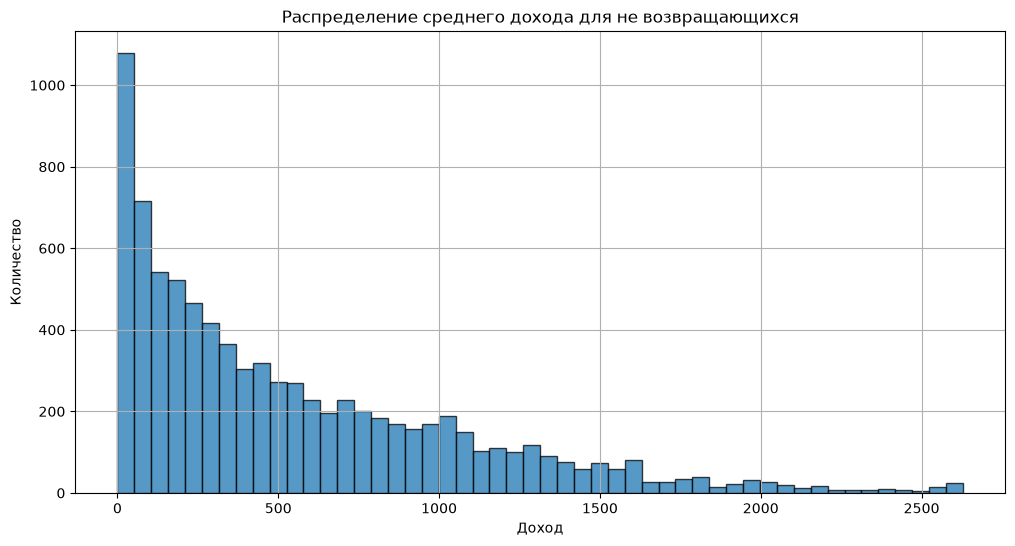

In [66]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))
filtered_orders = profile[profile['orders_count'] == 1]
# Строим гистограмму с помощью pandas через plot(kind='hist')
filtered_orders['avg_revenue_rub'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=50, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение среднего дохода для не возвращающихся')
plt.xlabel('Доход')
plt.ylabel('Количество')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

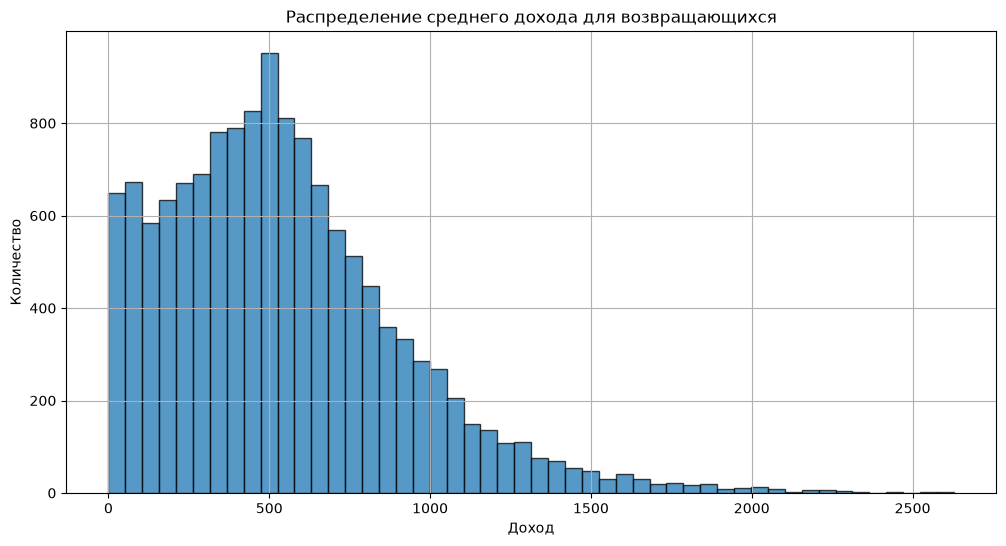

In [67]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))
filtered_returned = profile[profile['orders_count'] >= 2]
filtered_returned = filtered_returned.drop_duplicates(subset=['user_id'])
# Строим гистограмму с помощью pandas через plot(kind='hist')
filtered_returned['avg_revenue_rub'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=50, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение среднего дохода для возвращающихся')
plt.xlabel('Доход')
plt.ylabel('Количество')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

</font><font color='Blue'><b> Комментарий МК</b></font><br>
Не возвращающиеся пользователи чаще имеют среднюю выручку до 500 рублей. Больше всего значений находится около 0–100 рублей.
Возвращающиеся пользователи чаще имеют среднюю выручку от 200 до 800 рублей. Пик находится примерно в диапазоне 400–600 рублей.
В обеих группах встречаются значения до 2600 рублей, но их мало.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


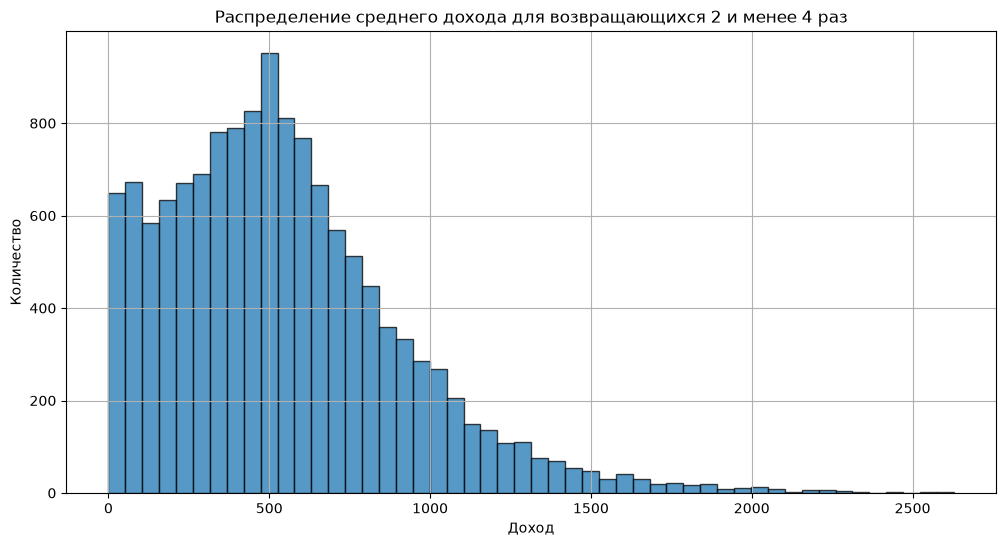

In [68]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))
filtered_returned_two = profile[
    (profile['orders_count'] >= 2) &
    (profile['orders_count'] <= 4)
]
filtered_returned_two = filtered_returned.drop_duplicates(subset=['user_id'])
# Строим гистограмму с помощью pandas через plot(kind='hist')
filtered_returned_two['avg_revenue_rub'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=50, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение среднего дохода для возвращающихся 2 и менее 4 раз')
plt.xlabel('Доход')
plt.ylabel('Количество')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

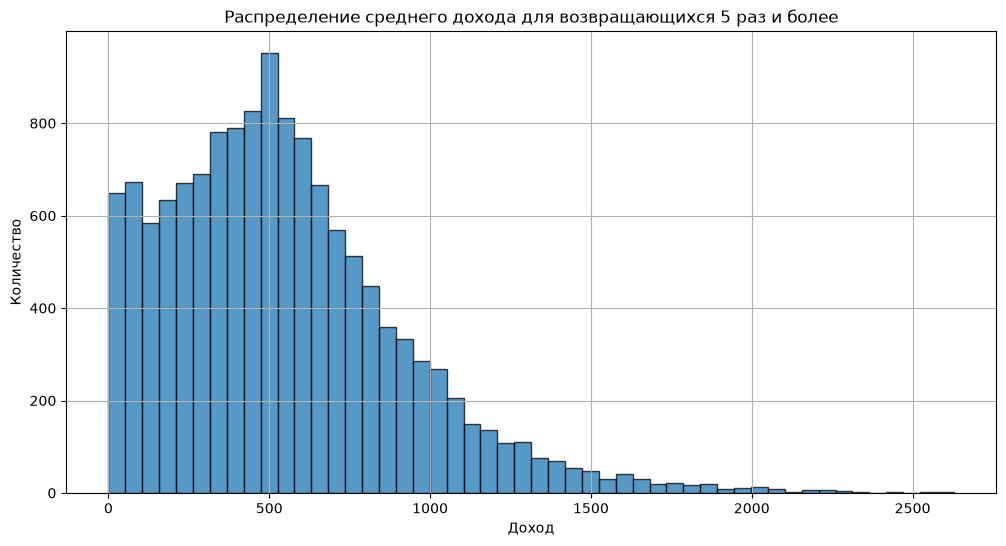

In [69]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))
filtered_returned_five = profile[
    (profile['orders_count'] >= 5)]
filtered_returned_five = filtered_returned.drop_duplicates(subset=['user_id'])
# Строим гистограмму с помощью pandas через plot(kind='hist')
filtered_returned_five['avg_revenue_rub'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=50, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение среднего дохода для возвращающихся 5 раз и более')
plt.xlabel('Доход')
plt.ylabel('Количество')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

</font><font color='Blue'><b> Комментарий МК</b></font><br>
В обеих группах основная средняя выручка находится примерно в диапазоне 200–900 рублей.
В обеих группах пик находится около 450–550 рублей.
Значения выше 1500 рублей встречаются редко.
У пользователей с 5 и более заказами распределение немного шире в области низкой выручки.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

<function matplotlib.pyplot.show(close=None, block=None)>

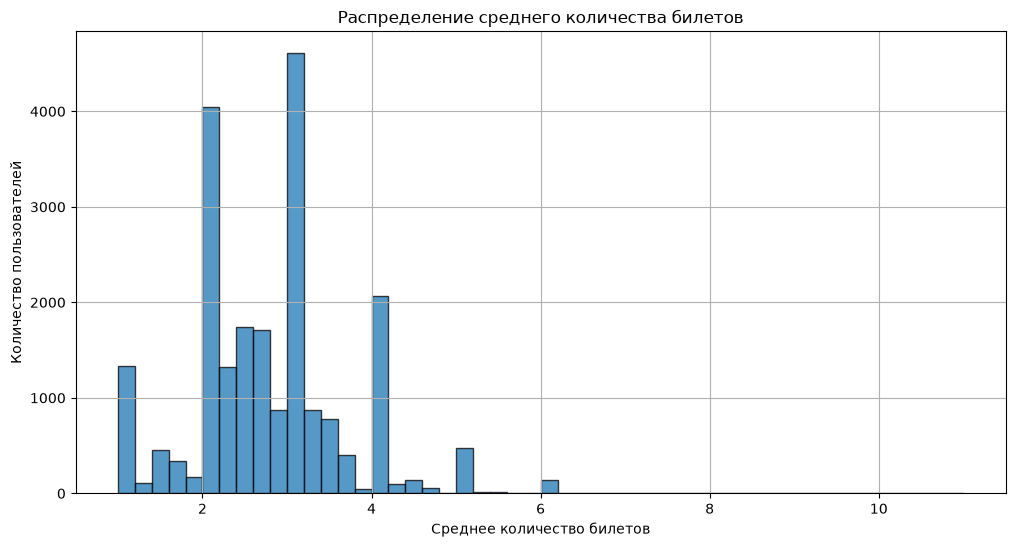

In [70]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))
filtered_tickets = profile.drop_duplicates(subset=['user_id'])
# Строим гистограмму с помощью pandas через plot(kind='hist')
filtered_tickets['avg_tickets_count'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=50, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение среднего количества билетов')
plt.xlabel('Среднее количество билетов')
plt.ylabel('Количество пользователей')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show

In [71]:
profile.loc[
    (profile['avg_tickets_count'] >= 1) &
    (profile['avg_tickets_count'] < 2),
    'category_ticket'
] = '1–2 билета'

profile.loc[
    (profile['avg_tickets_count'] >= 2) &
    (profile['avg_tickets_count'] < 3),
    'category_ticket'
] = '2–3 билета'

profile.loc[
    (profile['avg_tickets_count'] >= 3) &
    (profile['avg_tickets_count'] < 5),
    'category_ticket'
] = '3–5 билетов'

profile.loc[
    profile['avg_tickets_count'] >= 5,
    'category_ticket'
] = '5 и более'

In [72]:
filtered_tickets = profile.drop_duplicates('user_id')

filtered_tickets_per_category = (
    filtered_tickets
    .groupby('category_ticket')['user_id']
    .count()
)
filtered_tickets_per_category

category_ticket
1–2 билета     2410
2–3 билета     9695
3–5 билетов    9072
5 и более       661
Name: user_id, dtype: int64

In [73]:
share_yes = (
    filtered_tickets
    .groupby('category_ticket')['is_two_yes']
    .mean()
    .mul(100)
    .round(1)
)

share_yes

category_ticket
1–2 билета     51.2
2–3 билета     74.1
3–5 билетов    54.3
5 и более      18.8
Name: is_two_yes, dtype: float64

</font><font color='Blue'><b> Комментарий МК</b></font><br>
Самая высокая доля повторных покупателей наблюдается в сегменте «2–3 билета» — 74,1%. В сегментах «1–2 билета» и «3–5 билетов» доли близки: 51,2% и 54,3%. Самая низкая доля зафиксирована в сегменте «5 и более» — 18,8%. Следовательно, вероятность повторной покупки не увеличивается последовательно вместе со средним количеством билетов.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [74]:
#  сортируем заказы, чтобы первый заказ пользователя был первым
profile = profile.sort_values(['user_id', 'order_ts'])

#  определяем день недели заказа
profile['day_of_week'] = profile['order_ts'].dt.day_name()

#  оставляем первый заказ каждого пользователя
profile_first = profile.drop_duplicates(subset=['user_id'])

In [75]:
profile_day = (
    profile_first
    .groupby('day_of_week')['user_id']
    .count()
)

profile_day

day_of_week
Friday       3258
Monday       2931
Saturday     3456
Sunday       2810
Thursday     3119
Tuesday      3188
Wednesday    3076
Name: user_id, dtype: int64

In [76]:
profile_day_share = (
    profile_first
    .groupby('day_of_week')['is_two_yes']
    .mean()
    .mul(100)
    .round(1)
)

profile_day_share

day_of_week
Friday       59.8
Monday       63.2
Saturday     64.2
Sunday       60.5
Thursday     59.5
Tuesday      62.0
Wednesday    62.5
Name: is_two_yes, dtype: float64

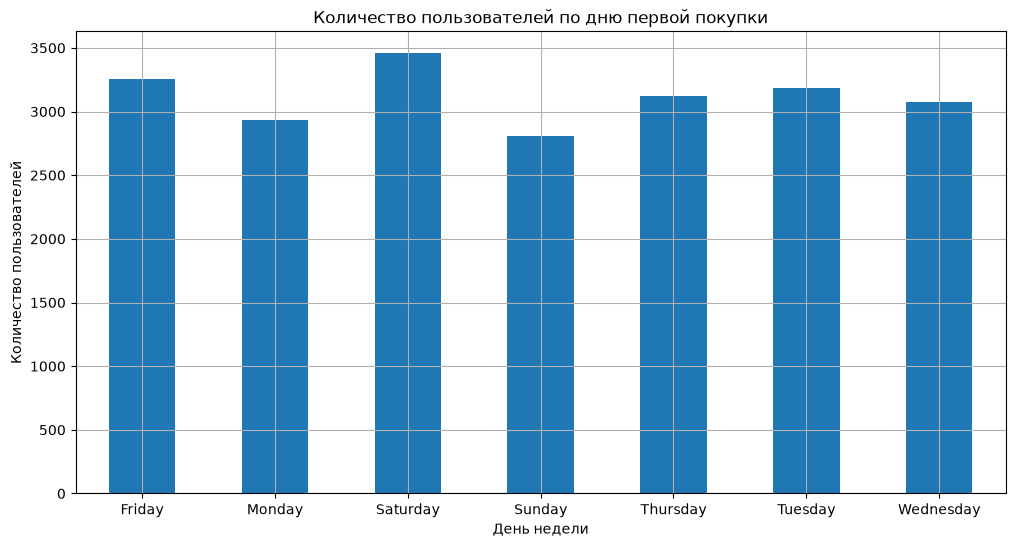

In [77]:
plt.figure(figsize=(12, 6))

profile_day.plot(
    kind='bar',
    rot=0,
    legend=False,
    title='Количество пользователей по дню первой покупки'
)

plt.xlabel('День недели')

# ИЗМЕНЕНО:
# было: plt.ylabel('Количество заказов')
plt.ylabel('Количество пользователей')

plt.grid()
plt.show()

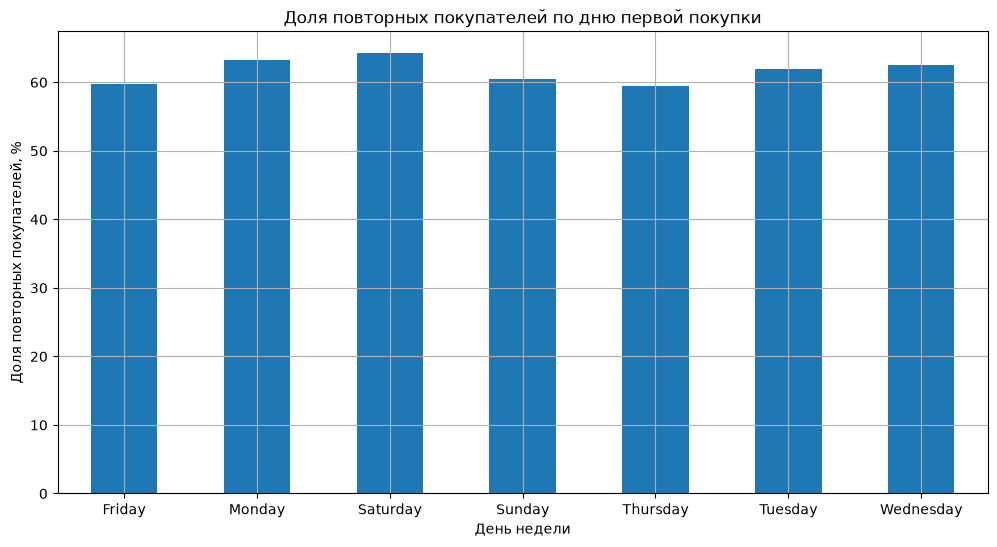

In [78]:
# ДОБАВЛЕНО
plt.figure(figsize=(12, 6))

profile_day_share.plot(
    kind='bar',
    rot=0,
    legend=False,
    title='Доля повторных покупателей по дню первой покупки'
)

plt.xlabel('День недели')
plt.ylabel('Доля повторных покупателей, %')
plt.grid()
plt.show()

</font><font color='Blue'><b> Комментарий МК</b></font><br>
Всего проанализировано 21 838 уникальных пользователей. Пользователи распределены по дням первой покупки достаточно равномерно. Больше всего пользователей совершили первую покупку в субботу — 3456, а меньше всего в воскресенье — 2810.

Доля повторных покупателей во все дни находится примерно на одном уровне — от 59,5% до 64,2%. Наибольшая доля наблюдается в субботу — 64,2%, а наименьшая в четверг — 59,5%. Разница составляет только 4,7 процентного пункта.

Таким образом, день недели, в который была совершена первая покупка, не оказывает заметного влияния на вероятность повторной покупки. Незначительные различия между днями могут быть связаны с обычными колебаниями данных.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [79]:
profile.loc[
    (profile['orders_count'] >= 2) &
    (profile['orders_count'] <= 4),
    'category_between_days'
] = '2–4 заказа'

profile.loc[
    (profile['orders_count'] >= 5), 
    'category_between_days'
] = '5 и более заказов'

In [80]:
filtered_dates = profile.drop_duplicates('user_id')

filtered_dates_per_category = (
    filtered_dates
    .groupby('category_between_days')['avg_days_between_orders']
    .mean()
)
filtered_dates_per_category

category_between_days
2–4 заказа           21.312544
5 и более заказов     9.572410
Name: avg_days_between_orders, dtype: float64

</font><font color='Blue'><b> Комментарий МК</b></font><br>
Для пользователей, совершивших 2–4 заказа, средний интервал между заказами составляет 21,3 дня. Для пользователей с 5 и более заказами средний интервал значительно меньше — 9,6 дня.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [81]:
for_phik = profile.drop_duplicates('user_id')
phik_matrix=for_phik[[ 'first_order_device',
    'avg_days_between_orders',
    'first_order_genre',
    'first_order_service',
    'first_order_region',
    'avg_tickets_count',
    'day_of_week',
    'orders_count']].phik_matrix(interval_cols=[
        'avg_days_between_orders',
        'avg_tickets_count',
        'orders_count'])
print('Корреляция признаков с orders_count')
phik_matrix.loc[phik_matrix.index != 'orders_count'][['orders_count']]

Корреляция признаков с orders_count


,orders_count
first_order_device,0.000000
avg_days_between_orders,0.000000
first_order_genre,0.000000
first_order_service,0.101877
first_order_region,0.128413
avg_tickets_count,0.000000
day_of_week,0.055553


In [82]:
profile.loc[
    (profile['orders_count'] == 1),
    'category_between_days'
] = '1 заказ'

In [83]:
for_phik = profile.drop_duplicates('user_id')
phik_matrix=for_phik[[ 'device_type_canonical', 
'avg_days_between_orders',
                      'first_order_genre',
 'event_type_main',                 
 'service_name',                     
 'region_name',                                                                                
 'category_ticket',               
 'day_of_week',  'category_between_days']].phik_matrix()
print('Корреляция признаков с category_between_days')
phik_matrix.loc[phik_matrix.index != 'category_between_days'][['category_between_days']]

interval columns not set, guessing: ['avg_days_between_orders']
Корреляция признаков с category_between_days


,category_between_days
device_type_canonical,0.016553
avg_days_between_orders,0.395443
first_order_genre,0.041889
event_type_main,0.041889
service_name,0.086580
region_name,0.126035
category_ticket,0.232820
day_of_week,0.046895


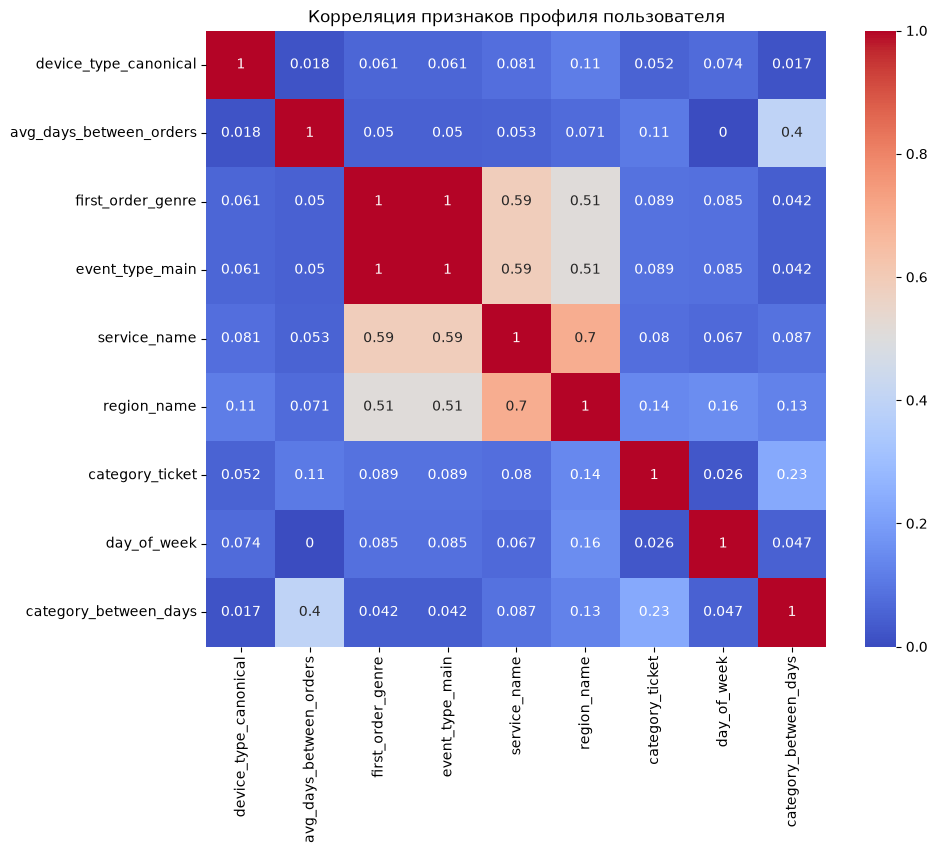

In [84]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    phik_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Корреляция признаков профиля пользователя')
plt.show()

In [85]:
profile.info()

<class 'pandas.DataFrame'>
RangeIndex: 287405 entries, 0 to 287404
Data columns (total 30 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   user_id                  287405 non-null  str           
 1   device_type_canonical    287405 non-null  str           
 2   order_id                 287405 non-null  int64         
 3   order_dt                 287405 non-null  datetime64[us]
 4   order_ts                 287405 non-null  datetime64[us]
 5   tickets_count            287405 non-null  int64         
 6   days_since_prev          265772 non-null  float64       
 7   event_id                 287405 non-null  int64         
 8   event_name               287405 non-null  str           
 9   event_type_main          287405 non-null  str           
 10  service_name             287405 non-null  str           
 11  region_name              287405 non-null  str           
 12  city_name                28

</font><font color='Blue'><b> Комментарий МК</b></font><br>
При анализе точного количества заказов все связи оказались слабыми. Самая высокая связь обнаружена у региона — 0,13 и билетного оператора — 0,10.

После разделения пользователей на группы результаты стали более заметными. Самая сильная связь выявлена между группой по числу заказов и средним интервалом между заказами — 0,47. Также заметна связь со средним количеством билетов — 0,35.

Остальные признаки имеют слабую связь: регион — 0,08, билетный оператор — 0,07, день недели — 0,04, устройство и жанр — около 0,03.

Таким образом, количество заказов сильнее всего связано со средним интервалом между покупками и средним количеством билетов. Характеристики первого заказа связаны с количеством покупок намного слабее. Следует учитывать, что интервал можно рассчитать только для пользователей, которые уже сделали повторный заказ.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

</font><font color='Blue'><b> Комментарий МК</b></font><br>
5. Общий вывод и рекомендации
В проекте были изучены данные о покупках билетов на Яндекс Афише. Изначально в таблице было 290 611 строк.

Выручка в тенге была переведена в рубли. Были удалены отрицательные значения выручки и самые крупные выбросы. Всего удалено 3206 строк, или 1,1% данных. Пропуски в количестве дней между заказами были оставлены, потому что у первой покупки нет предыдущего заказа.

После обработки в анализе осталось 21 838 пользователей. Для каждого пользователя был создан отдельный профиль.

Пользователи чаще всего впервые заходят с мобильных устройств. Самые популярные первые мероприятия — концерты. Среди регионов особенно выделяется Каменевский регион.

Тип первого мероприятия почти не влияет на возврат. Пользователи, впервые купившие билеты на спорт, возвращаются не чаще покупателей билетов на концерты. Поэтому первая гипотеза не подтвердилась.

Связи между популярностью региона и возвратом также не обнаружено. В небольших регионах доля возврата иногда выше, но там мало пользователей, поэтому такие результаты могут быть случайными.

Вернувшиеся пользователи обычно имеют более высокую среднюю выручку с заказа. Но между пользователями с 2–4 заказами и пользователями с 5 и более заказами большой разницы по выручке нет.

Чаще всего возвращаются пользователи, которые покупают в среднем 2–3 билета. Доля возврата в этой группе составляет 74,1%. Реже всего возвращаются пользователи, покупающие 5 и более билетов: их доля возврата составляет 18,8%.

День первой покупки почти не влияет на возврат. Доля повторных покупателей меняется от 59,5% до 64,2% в зависимости от дня недели. Эта разница небольшая.

Активные пользователи делают заказы чаще. У пользователей с 2–4 заказами средний перерыв составляет 21,3 дня. У пользователей с 5 и более заказами — 9,6 дня.

Рекомендации

Стоит обратить внимание на пользователей, которые покупают 2–3 билета: они возвращаются чаще других.

Пользователям, купившим 5 и более билетов, можно отправлять специальные предложения, чтобы повысить вероятность возврата.

Повторные предложения лучше отправлять в первые 10–20 дней после заказа.

Не стоит строить маркетинговую стратегию только на дне недели, типе мероприятия или регионе. Эти признаки слабо связаны с возвратом пользователей.

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**